# Penugasan 3: Perbandingan Deteksi Tepi dengan Foto Sendiri

Tujuan tugas ini adalah membandingkan hasil deteksi tepi dari beberapa operator menggunakan foto milik sendiri.

Ketentuan penggunaan gambar:
1. Nama file gambar: penugasan3.jpg
2. Lokasi file: letakkan di folder yang sama dengan notebook ini (folder job2)
3. Jika ingin ganti foto, cukup timpa file lama dengan nama dan lokasi yang sama

Gambar loaded: C:\Users\user\Documents\0-tugas-IK-D\S6\pengolahan citra\ngoding\job2\penugasan3.jpg


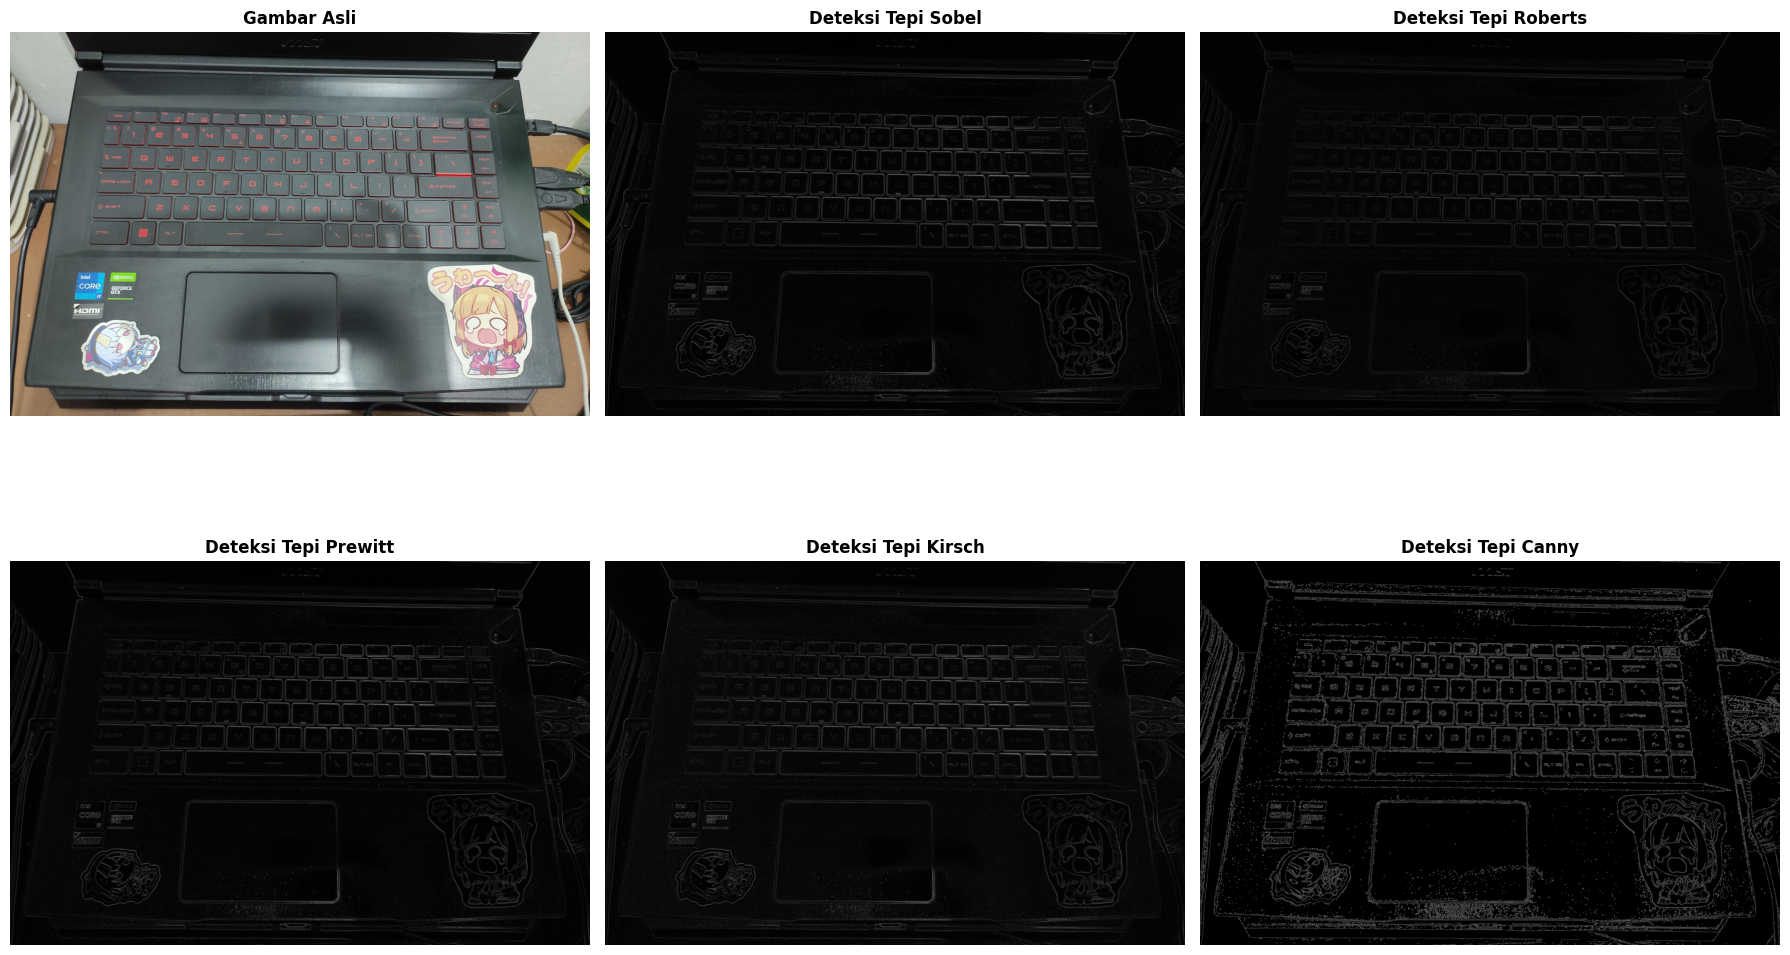


=== INFORMASI GAMBAR ===
Path: penugasan3.jpg
Shape: (3059, 4624)
Dtype: float64
Min value: 0.0000
Max value: 1.0000
Mean value: 0.4210

=== PERBANDINGAN OPERATOR DETEKSI TEPI ===
Sobel        - Min: 0.0000, Max: 0.6823, Mean: 0.0236
Roberts      - Min: 0.0000, Max: 0.7463, Mean: 0.0219
Prewitt      - Min: 0.0000, Max: 0.6620, Mean: 0.0230
Kirsch       - Min: 0.0000, Max: 243.0000, Mean: 10.1179
Canny        - Min: 0.0000, Max: 1.0000, Mean: 0.0434


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, filters, feature
from skimage.filters.rank import gradient
from skimage.morphology import disk
from pathlib import Path

# ===================== LANGKAH 1: AMBIL FOTO SENDIRI =====================
# Wajib gunakan file: penugasan3.jpg
# Letakkan file di folder job2 (folder notebook ini).

candidate_paths = [
    Path("penugasan3.jpg"),
    Path("job2") / "penugasan3.jpg",
]

image_path = None
for p in candidate_paths:
    if p.exists():
        image_path = p
        break

if image_path is None:
    raise FileNotFoundError(
        "File penugasan3.jpg tidak ditemukan. "
        "Taruh file di folder job2, lalu jalankan ulang cell."
    )

image = plt.imread(image_path)
print(f"Gambar loaded: {image_path.resolve()}")

# Normalisasi gambar jika nilai pixel masih 0-255
if image.max() > 1:
    image = image / 255.0

# Ubah ke grayscale jika perlu
if image.ndim == 3:
    image_gray = color.rgb2gray(image)
    image_display = image
else:
    image_gray = image
    image_display = image

# ===================== LANGKAH 2: DETEKSI TEPI =====================
sobel_edge = filters.sobel(image_gray)
roberts_edge = filters.roberts(image_gray)
prewitt_edge = filters.prewitt(image_gray)
kirsch_edge = gradient((image_gray * 255).astype(np.uint8), disk(1))
canny_edge = feature.canny(image_gray, sigma=1)

# ===================== LANGKAH 3: VISUALISASI HASIL =====================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
ax = axes.ravel()

if image_display.ndim == 3:
    ax[0].imshow(image_display)
else:
    ax[0].imshow(image_display, cmap='gray')
ax[0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
ax[0].axis("off")

ax[1].imshow(sobel_edge, cmap='gray')
ax[1].set_title("Deteksi Tepi Sobel", fontsize=12, fontweight='bold')
ax[1].axis("off")

ax[2].imshow(roberts_edge, cmap='gray')
ax[2].set_title("Deteksi Tepi Roberts", fontsize=12, fontweight='bold')
ax[2].axis("off")

ax[3].imshow(prewitt_edge, cmap='gray')
ax[3].set_title("Deteksi Tepi Prewitt", fontsize=12, fontweight='bold')
ax[3].axis("off")

ax[4].imshow(kirsch_edge, cmap='gray')
ax[4].set_title("Deteksi Tepi Kirsch", fontsize=12, fontweight='bold')
ax[4].axis("off")

ax[5].imshow(canny_edge, cmap='gray')
ax[5].set_title("Deteksi Tepi Canny", fontsize=12, fontweight='bold')
ax[5].axis("off")

plt.tight_layout()
plt.show()

# ===================== LANGKAH 4: ANALISIS SINGKAT =====================
print("\n=== INFORMASI GAMBAR ===")
print(f"Path: {image_path}")
print(f"Shape: {image_gray.shape}")
print(f"Dtype: {image_gray.dtype}")
print(f"Min value: {image_gray.min():.4f}")
print(f"Max value: {image_gray.max():.4f}")
print(f"Mean value: {image_gray.mean():.4f}")

print("\n=== PERBANDINGAN OPERATOR DETEKSI TEPI ===")
edges = {
    'Sobel': sobel_edge,
    'Roberts': roberts_edge,
    'Prewitt': prewitt_edge,
    'Kirsch': kirsch_edge.astype(float),
    'Canny': canny_edge.astype(float),
}

for name, edge in edges.items():
    print(f"{name:12} - Min: {edge.min():.4f}, Max: {edge.max():.4f}, Mean: {edge.mean():.4f}")